Practica de visualizaciones a partir del siguiente recurso: [¿Cómo elegir correctamente los gráficos en Python?](https://www.youtube.com/watch?v=P1H4R14pd7A&themeRefresh=1)

### 1. Preparación del entorno y los datos
Primero, es necesario importar las librerías y cargar el dataset de ejemplo (`tips`) que contiene información sobre propinas en un restaurante.

```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Cargar el dataset de ejemplo de Seaborn
df = sns.load_dataset('tips')
# Ver las primeras filas para entender la estructura (total_bill, tip, sex, smoker, day, time, size)
df.head()
```

---

### 2. Gráficos para una sola variable (Univariante)
Para las variables **categóricas** (como el género o el día), lo ideal es realizar un recuento de frecuencias antes de graficar. Para las **numéricas**, se analizan distribuciones.

```python
# --- Una variable CATEGÓRICA ---
# Recuento y gráfico de sectores (pie chart)
tabla_sexo = df['sex'].value_counts()
tabla_sexo.plot.pie(startangle=90)
plt.show()

# Gráfico de barras (bar plot) para variables ordinales o nominales
df['day'].value_counts().plot.bar()
plt.show()

# --- Una variable NUMÉRICA ---
# Histograma con niveles de desglose (bins)
df['tip'].plot.hist(bins=20)
plt.show()

# Gráfico de densidad (KDE)
df['tip'].plot.kde()
plt.show()

# Gráfico de caja (Boxplot)
df['tip'].plot.box()
plt.show()
```

---

### 3. Gráficos para dos variables (Bivariante)
Dependiendo de si las variables son categóricas o numéricas, se utilizan diferentes técnicas.

```python
# --- Dos variables CATEGÓRICAS ---
# Usando una tabla de doble entrada (crosstab) y barras agrupadas
pd.crosstab(df['sex'], df['day']).plot.bar()
plt.show()

# Barras apiladas (stacked) para ver porcentajes o totales
pd.crosstab(df['day'], df['sex']).plot.bar(stacked=True)
plt.show()

# --- Dos variables NUMÉRICAS ---
# Gráfico de dispersión (Scatter Plot) sencillo con Pandas
df.plot.scatter(x='total_bill', y='tip')
plt.show()

# Scatter Plot con recta de regresión e intervalo de confianza usando Seaborn
sns.lmplot(data=df, x='total_bill', y='tip')
plt.show()

# --- Una variable CATEGÓRICA y una NUMÉRICA ---
# Gráfico de barras con el promedio (ej. propina media por día)
df.groupby('day')['tip'].mean().plot.bar()
plt.show()

# Boxplot para ver la distribución de una numérica en categorías
sns.boxplot(data=df, x='day', y='tip')
plt.show()
```

---

### 4. Gráficos para más de dos variables (Multivariante)
Aquí se añade complejidad mediante el uso de colores (`hue`), tamaños (`size`) o divisiones por filas y columnas (`row`, `col`).

```python
# Gráfico de violín partido por una variable (sexo) con colores
sns.violinplot(data=df, x='day', y='tip', hue='sex', split=True)
plt.show()

# Scatter plot complejo con 6 variables representadas:
# x (total_bill), y (tip), hue (sexo), col (fumador), row (momento del día), size (comensales)
sns.relplot(
    data=df, 
    x='total_bill', 
    y='tip', 
    hue='sex', 
    col='smoker', 
    row='time', 
    size='size'
)
plt.show()
```

---

### 5. Gráficos interactivos con Plotly
Finalmente, para obtener un gráfico que permita hacer zoom y ver detalles al pasar el ratón, se utiliza **Plotly**.

```python
# Scatter plot interactivo con color y símbolos diferentes para categorías
fig = px.scatter(
    df, 
    x='total_bill', 
    y='tip', 
    color='sex', 
    symbol='smoker'
)
fig.show()
```

Este código cubre la progresión desde el análisis descriptivo básico hasta visualizaciones multivariantes complejas mencionadas en las fuentes.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Cargar el dataset de ejemplo de Seaborn
df = sns.load_dataset('tips')

In [ ]:
# Ver las primeras filas para entender la estructura (total_bill, tip, sex, smoker, day, time, size)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.shape

(244, 7)

In [4]:
# 1 cat --> no puedo pasarle directamente la variable, siempre debo pedirle que me haga un recuento
df["sex"].value_counts()#.plot.pie()

sex
Male      157
Female     87
Name: count, dtype: int64

<Axes: ylabel='count'>

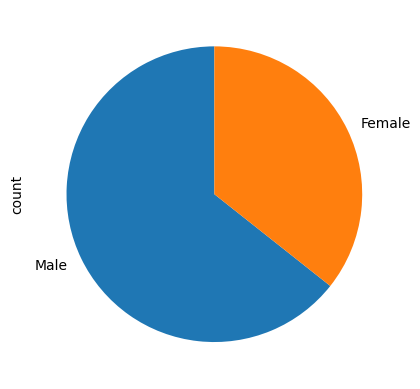

In [5]:
grup_sex=df["sex"].value_counts() #por defecto sale ordenado ascendente
grup_sex.plot.pie(startangle=90)

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_88122/2999127814.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")["size"].count().plot.pie(startangle=90) #lo pasamos como una serie o con pie(subplots=True)


<Axes: ylabel='size'>

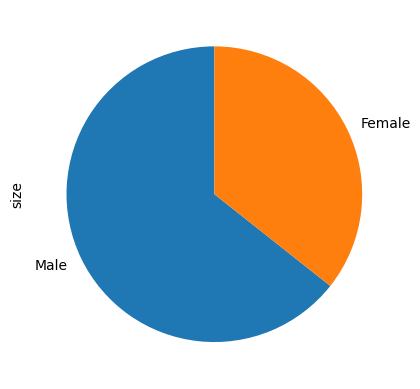

In [ ]:
#ESTO ESTA MAL
#otro ejemplo de pie pero con groupby, PERO ES EJEMPLIFICATIVO NO ES BUENO PARA una numerica y 1 categorica -> BARRAS
df.groupby("sex")["size"].count().plot.pie(startangle=90) #lo pasamos como una serie o con pie(subplots=True)

<Axes: xlabel='sex'>

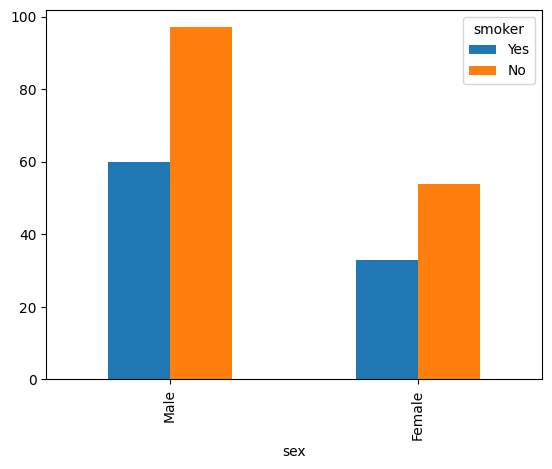

In [45]:
pd.crosstab(df["sex"], df["smoker"]).plot.bar()

<Axes: xlabel='day'>

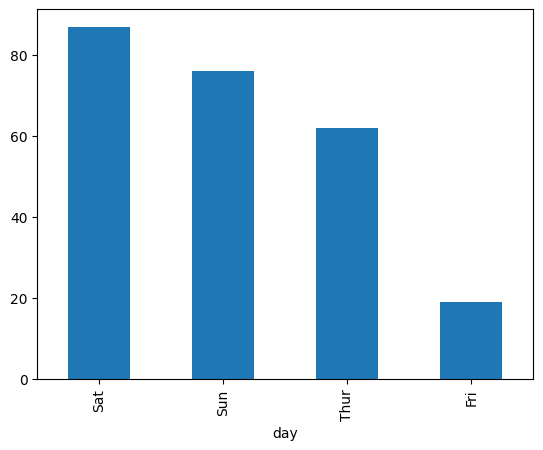

In [6]:
df["day"].value_counts().plot.bar()

<Axes: ylabel='Frequency'>

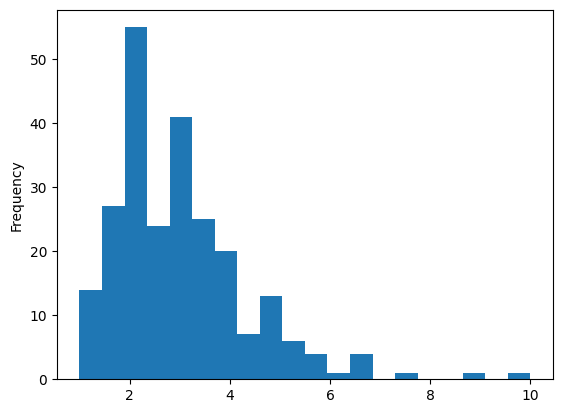

In [7]:
# 1 num
df["tip"].plot.hist(bins=20)#; para hacer desaparecer el texto que a veces aparece

<Axes: ylabel='Density'>

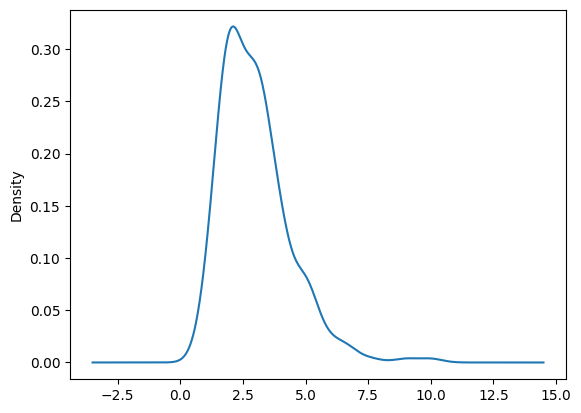

In [8]:
df["tip"].plot.kde()

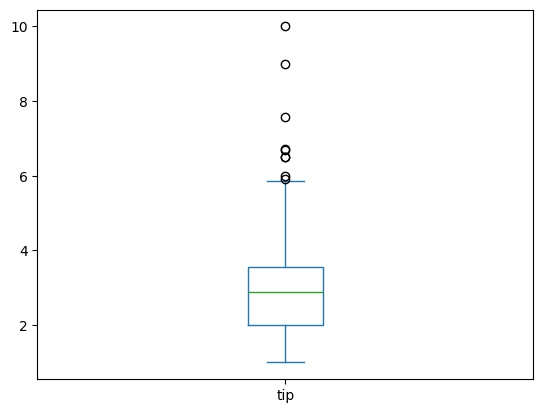

In [9]:
df["tip"].plot.box();

In [ ]:
# 2 cat - lo mejor es hacer un crosstab (una tabla que es como la base de un heatmap) - con un groupby queda peor
pd.crosstab(df["sex"], df["day"])

day,Thur,Fri,Sat,Sun
sex,,,,
Male,30,10,59,58
Female,32,9,28,18


In [11]:
pd.crosstab(df["sex"], df["day"]).transpose()

sex,Male,Female
day,,
Thur,30,32
Fri,10,9
Sat,59,28
Sun,58,18


<Axes: xlabel='sex'>

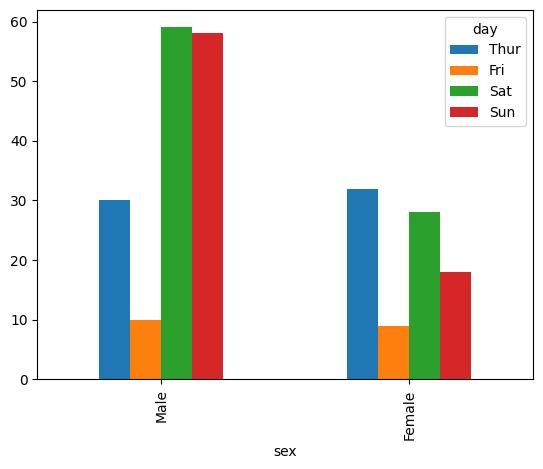

In [12]:
pd.crosstab(df["sex"], df["day"]).plot.bar()

<Axes: xlabel='day'>

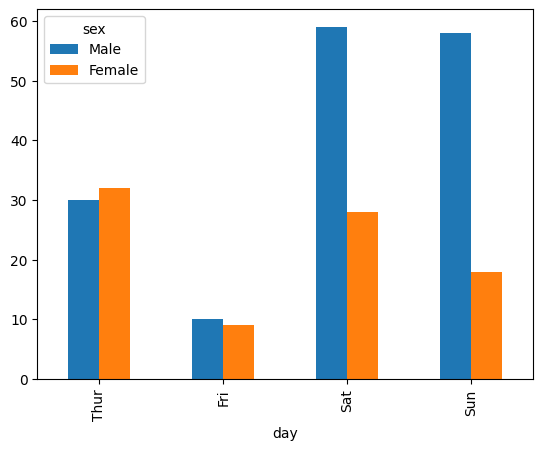

In [13]:
pd.crosstab(df["sex"], df["day"]).transpose().plot.bar()

<Axes: xlabel='day'>

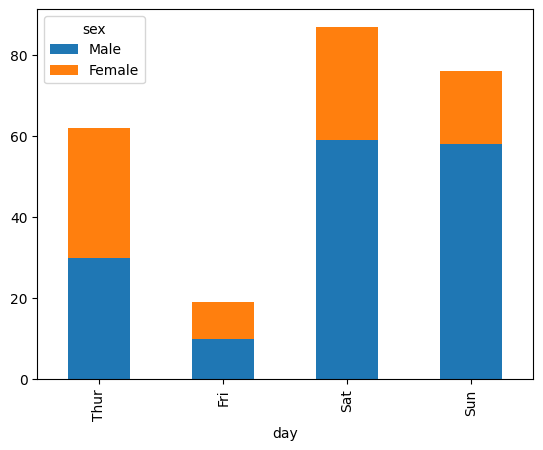

In [14]:
pd.crosstab(df["sex"], df["day"]).transpose().plot.bar(stacked=True)

    intentar hacer el grafico anterior apilado 100%, normalizando el crosstab

<Axes: xlabel='total_bill', ylabel='tip'>

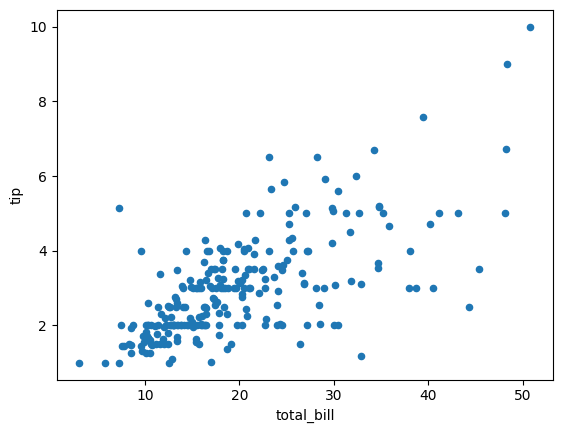

In [15]:
# 2 num - con estas variables podriamos hacerlo ya con seaborn que es interesante
df.plot.scatter(x="total_bill", y="tip") #correlacion positiva ;)

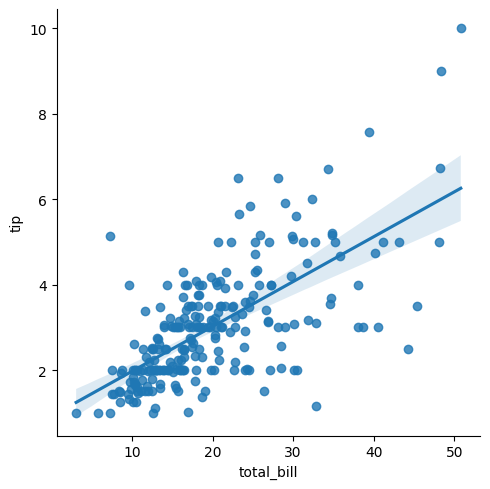

In [16]:
#ejemplo con seaborn
sns.lmplot(data=df, x="total_bill", y="tip") #incluye inetrvalo de confianza

In [17]:
# 1 cat y 1 num - en estecaso si el num es un promedio mejor usar groupby
tip_sex=df.groupby("sex")[["tip"]].mean()
tip_sex

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_88122/2763733095.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tip_sex=df.groupby("sex")[["tip"]].mean()


,tip
sex,
Male,3.089618
Female,2.833448


<Axes: xlabel='sex'>

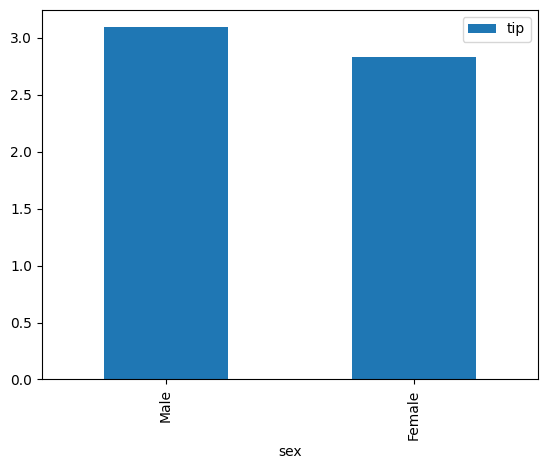

In [18]:
tip_sex.plot.bar()

/var/folders/n6/b047z_cs09zgcrm2gkjd3hr00000gn/T/ipykernel_88122/334535885.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("day")["tip"].mean().plot.bar() #solo un corchete para que no salga la leyenda


<Axes: xlabel='day'>

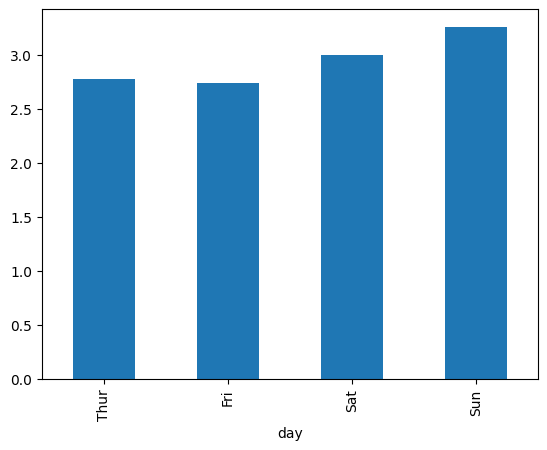

In [19]:
df.groupby("day")["tip"].mean().plot.bar() #solo un corchete para que no salga la leyenda

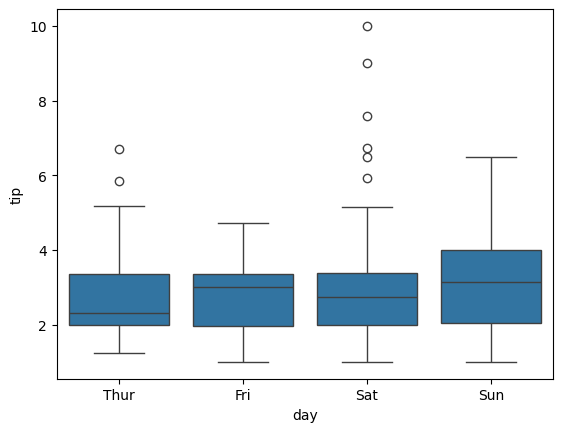

In [20]:
#otro ejemplo para ver medias es el boxplot, esta vez en seaborn
sns.boxplot(df, x="day", y="tip");

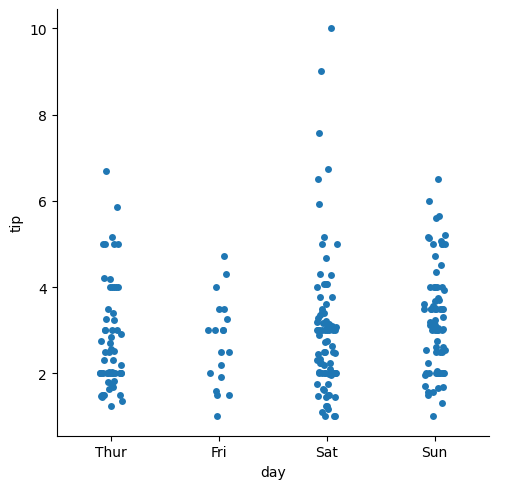

In [21]:
sns.catplot(df, x="day", y="tip"); #este es muy curioso: investigar +

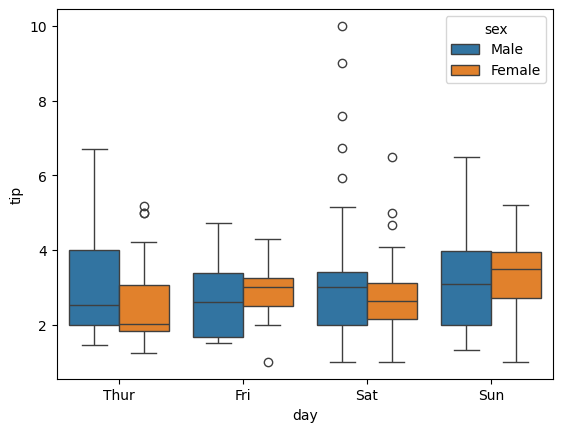

In [22]:
# >2 var
sns.boxplot(df, x="day", y="tip", hue="sex");

<Axes: title={'center': 'tip'}, xlabel='[day, sex]'>

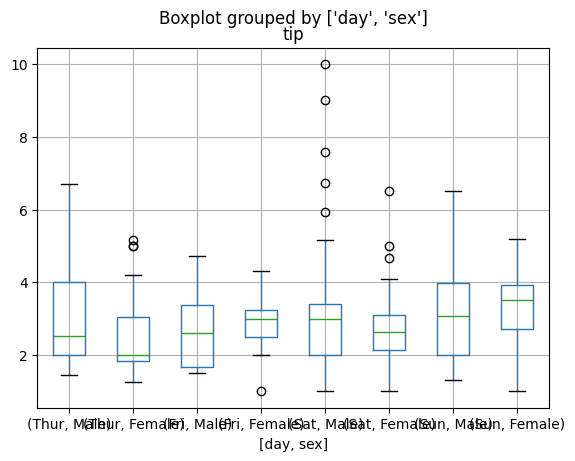

In [23]:
#comparación: no se ve bien con solo pandas
df.boxplot(column="tip", by=["day", "sex"])

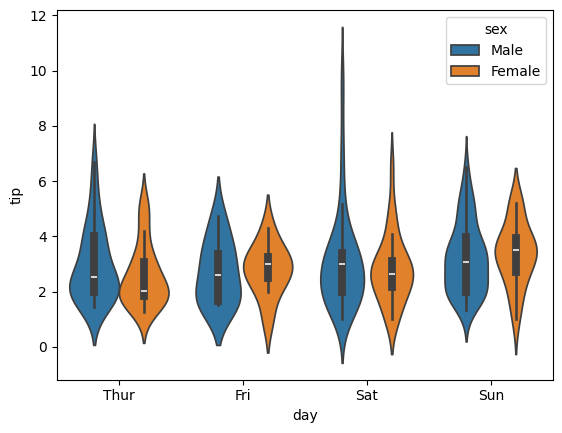

In [24]:
sns.violinplot(df, x="day", y="tip", hue="sex");

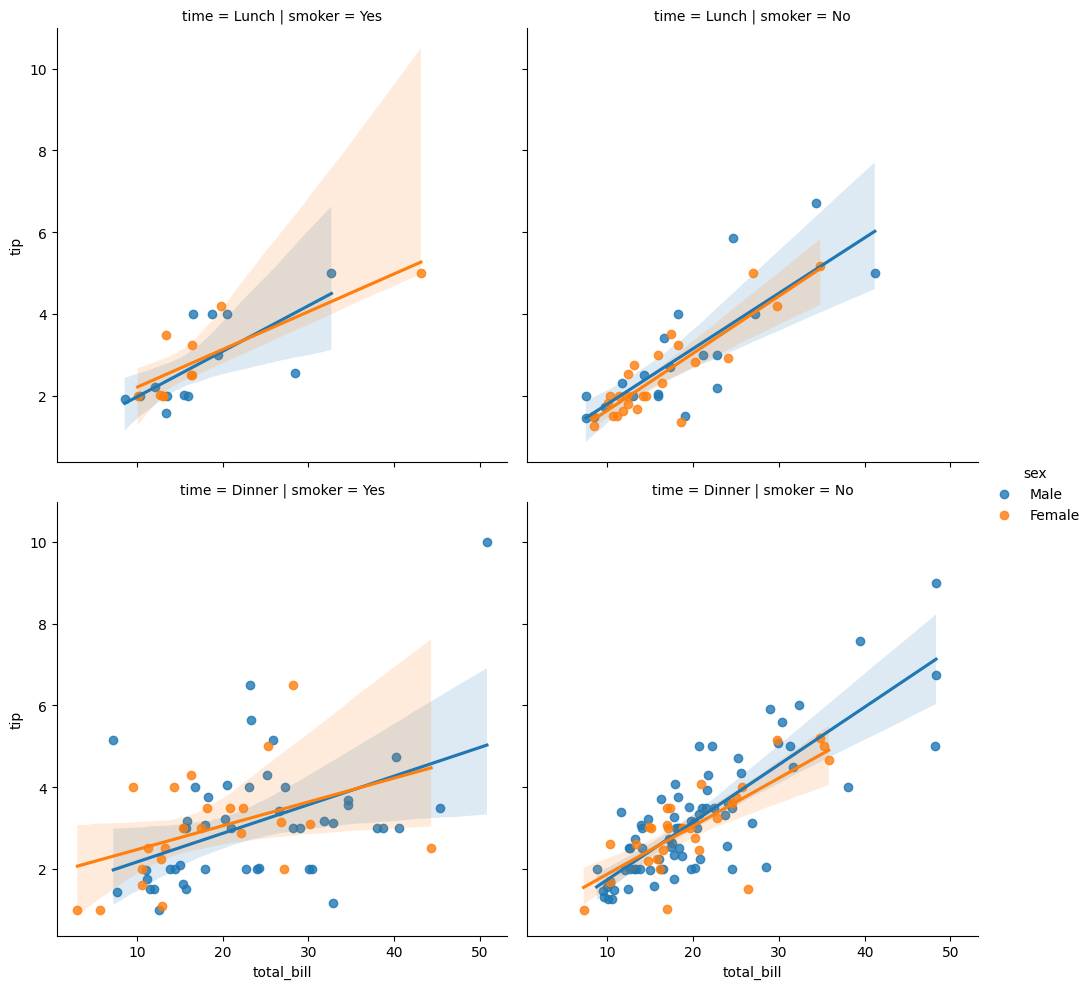

In [25]:
#matriz de graficos
sns.lmplot(data=df, x="total_bill", y="tip", hue="sex", col="smoker", row="time") #no hay gran diferencia en tendencia entre hombres y mujeres

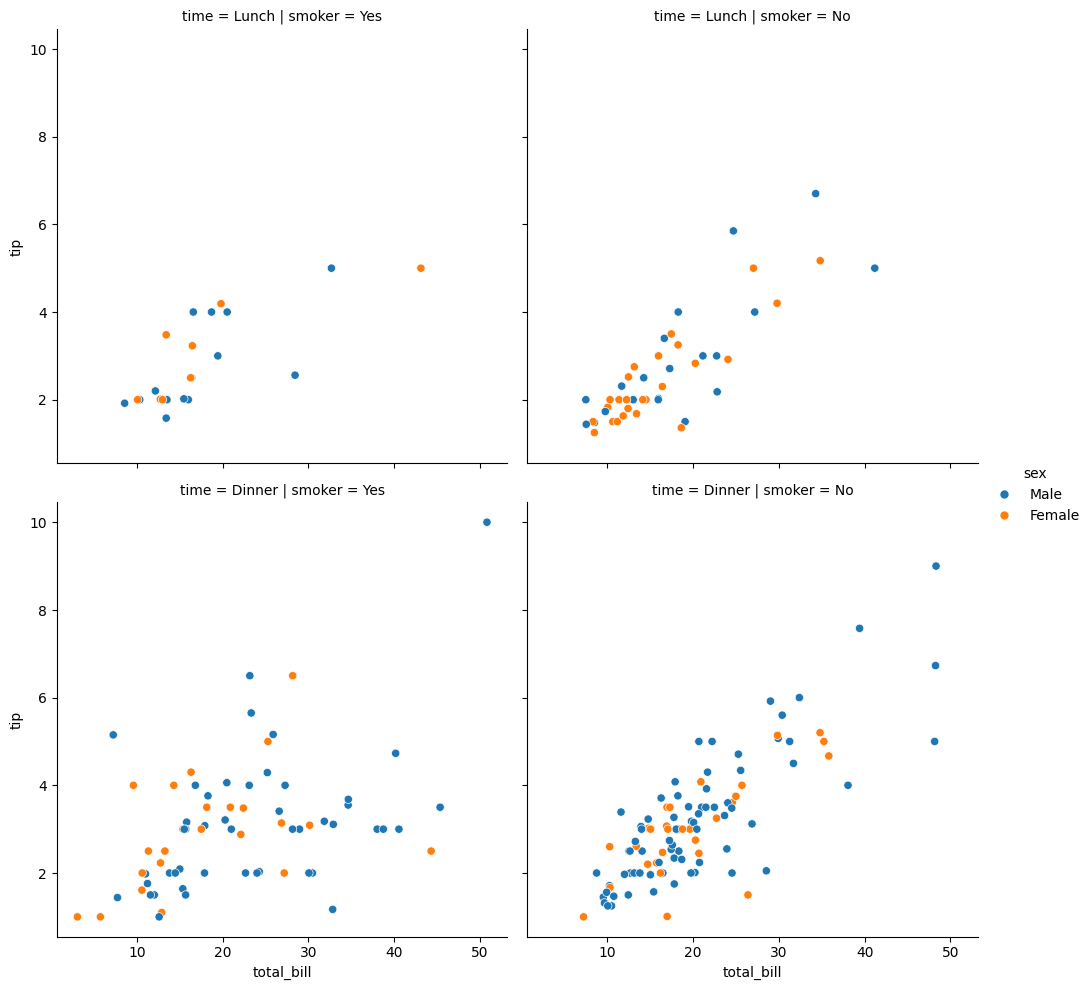

In [26]:
sns.relplot(data=df, x="total_bill", y="tip", hue="sex", col="smoker", row="time")

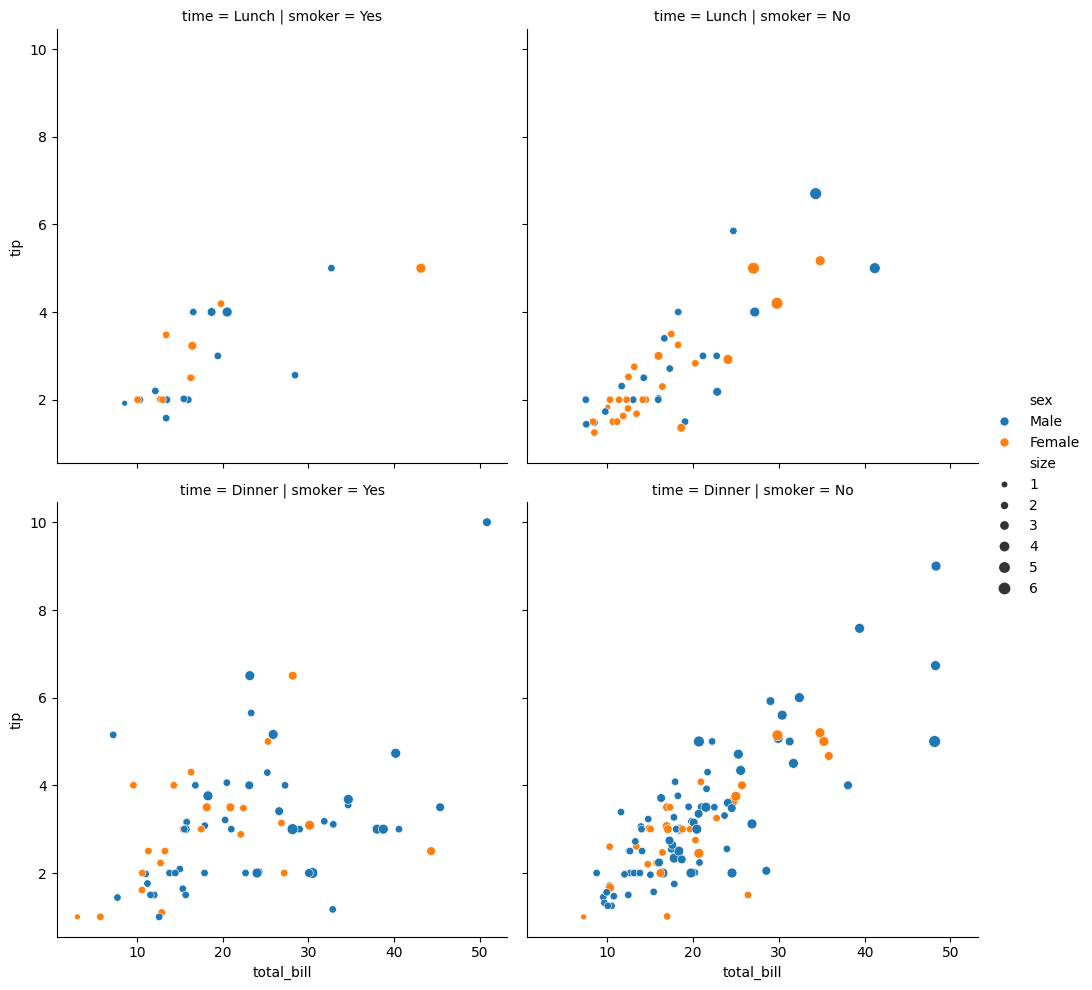

In [27]:
sns.relplot(data=df, x="total_bill", y="tip", hue="sex", col="smoker", row="time", size="size") #mucha variables: 6

In [30]:
fig= px.scatter(df, x="total_bill", y="tip", color="sex", symbol="smoker")
fig.show()